# 01 — EDA (short)

Distributions, coverage, confirm median WER + median-denominator BRI.
**No strategy crosstabs** (those are notebook 02 / Theme 1).

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from tiktok_brand.analysis.data import (
    load_feature_table,
    project_paths,
    coverage_summary,
    coverage_by_brand,
)
from tiktok_brand.analysis.metrics import outcome_health, leakage_checklist
from tiktok_brand.analysis.plots import sample_mix_bars, outcome_dist_charts, coverage_bars

PATHS = project_paths(ROOT / "configs" / "project.yaml")
df = load_feature_table(PATHS["feature_table"])
df.shape


(4457, 120)

## 1. Sample mix

brand:
 brand
nike      2317
adidas    2140
Name: count, dtype: int64

source_type:
 source_type
hashtag    3175
user       1282
Name: count, dtype: int64

post_date: 2019-02-07 → 2026-04-03


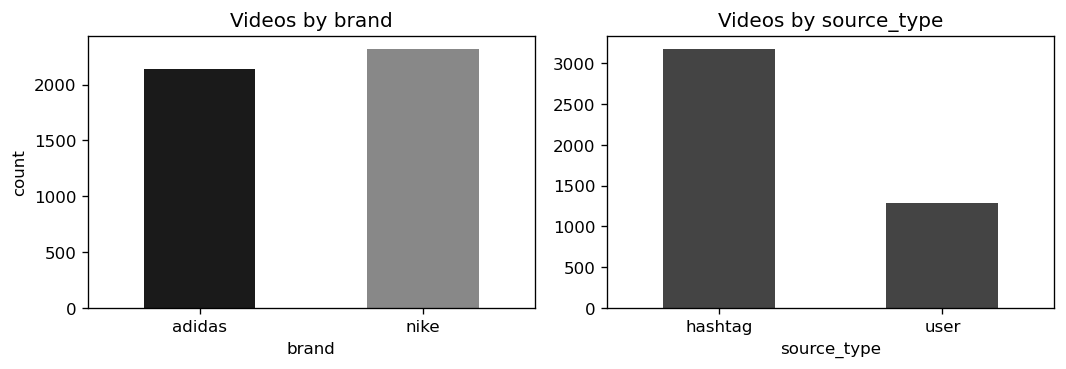

In [2]:
print("brand:\n", df["brand"].value_counts())
print("\nsource_type:\n", df["source_type"].value_counts())
print("\npost_date:", df["post_date"].min(), "→", df["post_date"].max())
sample_mix_bars(df)


## 2. Outcome health (views / WER / BRI)

BRI median by brand (expect ~1):
brand
adidas    1.0
nike      1.0
Name: brand_relative_engagement_index, dtype: float64


,view_count,weighted_engagement_rate,brand_relative_engagement_index
n,4.457000e+03,4453.000000,4453.000000
mean,1.001800e+06,0.008350,1.297886
median,1.134950e+05,0.006387,1.000000
std,3.849793e+06,0.007561,1.154289
p90,2.177029e+06,0.017292,2.676216
p99,1.353944e+07,0.032600,5.169742
max,1.145944e+08,0.150000,21.424809
skew,1.342608e+01,4.208107,3.771347
mean_over_median,8.826823e+00,1.307368,1.297886


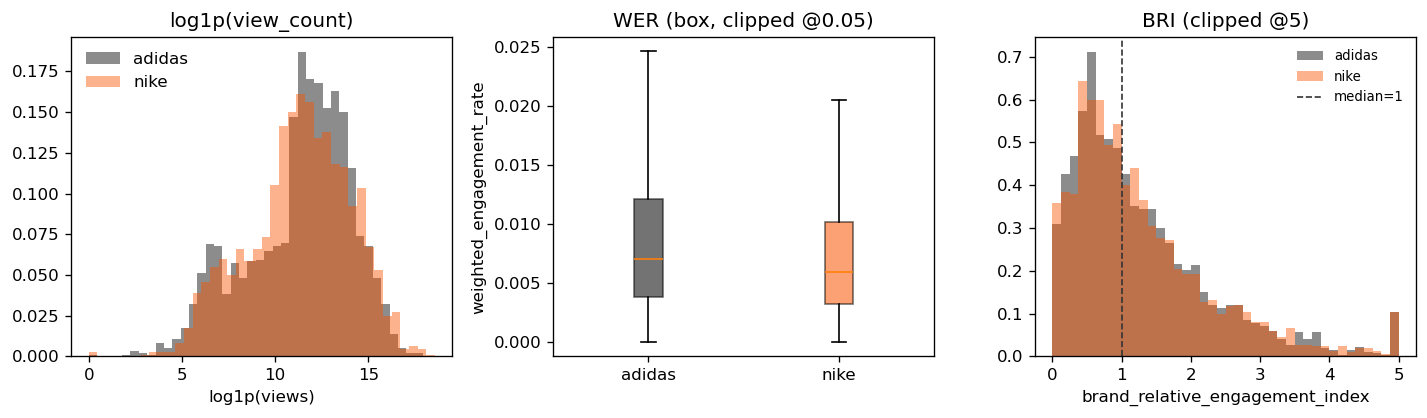

In [3]:
# stats as rows, metrics as columns
display(outcome_health(df).T)
print("BRI median by brand (expect ~1):")
print(df.groupby("brand")["brand_relative_engagement_index"].median())
outcome_dist_charts(df)


## 3. Coverage matrix

,column,present,filled,rate
0,content_type,True,887,0.199013
1,social_mechanic,True,552,0.123850
2,brand_styles,True,1033,0.231770
3,product_lines,True,1218,0.273278
4,visual_format,True,3764,0.844514
5,visual_setting,True,3764,0.844514
6,caption_en,True,3795,0.851470
7,clip_alignment_mean,True,3228,0.724254
8,content_cluster_id_clean_k12,True,4422,0.992147
9,text_embedding,True,4430,0.993942


,brand,column,present,filled,rate
0,adidas,content_type,True,471,0.220093
1,adidas,social_mechanic,True,258,0.120561
2,adidas,brand_styles,True,508,0.237383
3,adidas,product_lines,True,743,0.347196
4,adidas,visual_format,True,1754,0.819626
5,adidas,visual_setting,True,1754,0.819626
6,adidas,caption_en,True,1791,0.836916
7,adidas,clip_alignment_mean,True,1473,0.688318
8,adidas,content_cluster_id_clean_k12,True,2122,0.991589
9,adidas,text_embedding,True,2125,0.992991


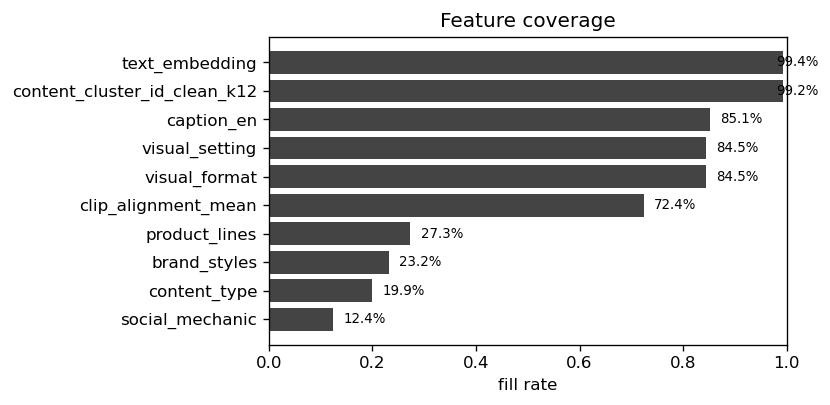

In [4]:
COV_COLS = [
    "content_type",
    "social_mechanic",
    "brand_styles",
    "product_lines",
    "visual_format",
    "visual_setting",
    "caption_en",
    "clip_alignment_mean",
    "content_cluster_id_clean_k12",
    "text_embedding",
]
cov = coverage_summary(df, COV_COLS)
display(cov)
display(coverage_by_brand(df, COV_COLS))
coverage_bars(cov)


## 4. Leakage checklist

In [5]:
for i, line in enumerate(leakage_checklist(), 1):
    print(f"{i}. {line}")

1. Do not use absolute like/comment/share/collect counts as features to predict WER/BRI.
2. Do not use BRI as the headline KPI for Nike vs Adidas brand strength (use median WER / views).
3. Exploding multi-label columns inflates row counts — report coverage_n vs source_n.
4. Sparse rules (content_type ~20%, social_mechanic ~12%): always show labeled subset size.
5. Predictive models (notebook 03): Y = brand_relative_engagement_index (median-denominator).
